# Classification: SVM, Random Forest (Compare on the same dataset using various performance matrices like acc, recall. Before that, show the distribution of data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn. metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the Iris dataset
df = pd.read_csv('Iris.csv')
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
# Define features (x) and target (y)
x = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']
print(x[:5])
print(y[:5])

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


Class Distribution:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


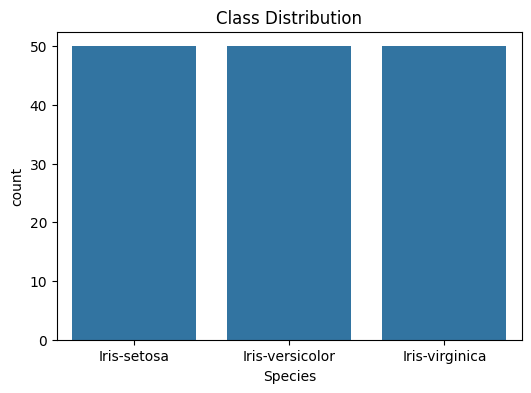

In [4]:
# Explore class distribution
print("Class Distribution:\n", y.value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

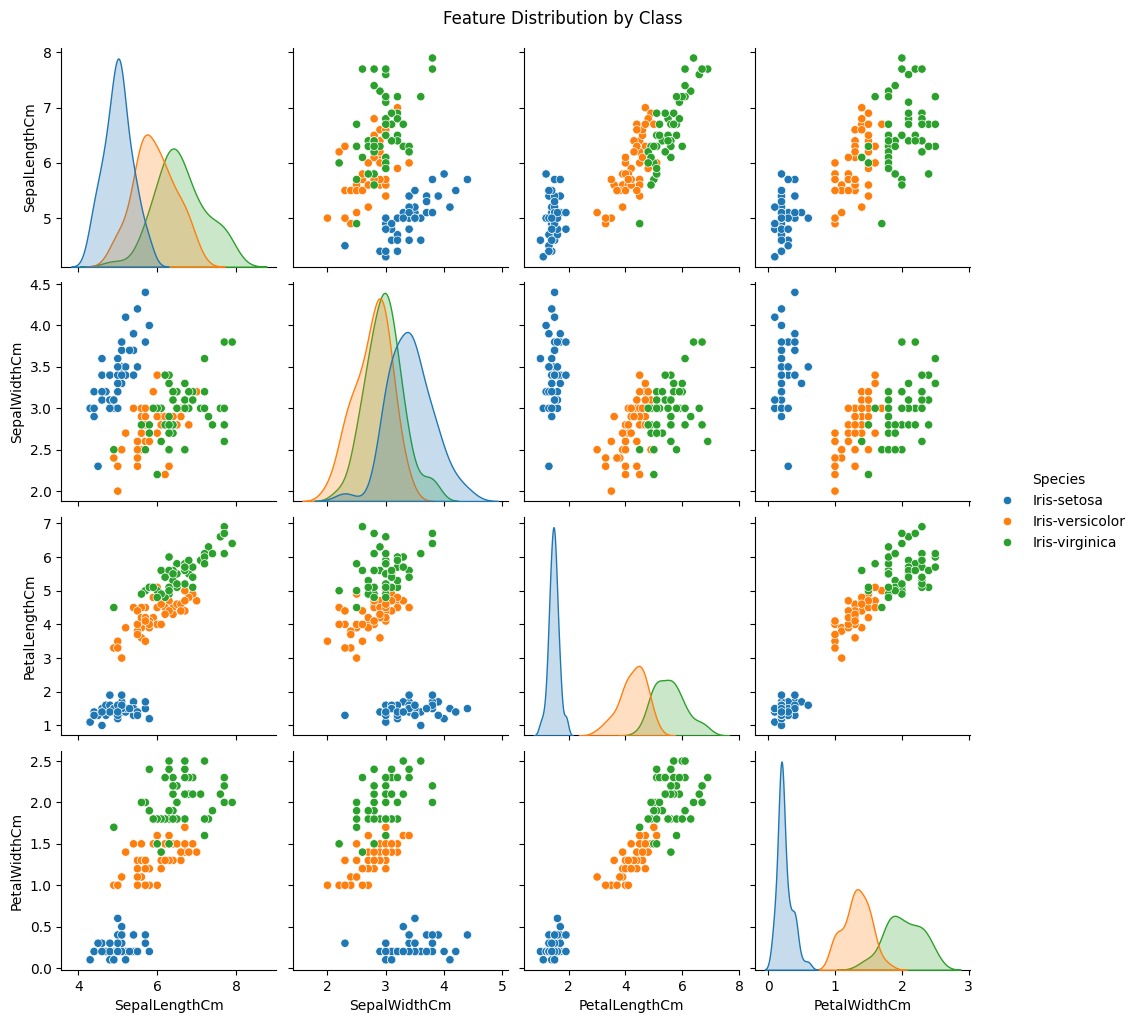

In [5]:
# Show feature distribution by class
sns.pairplot(pd.concat([x, y], axis=1), hue='Species')
plt.suptitle("Feature Distribution by Class", y=1.02)
plt.show()

In [6]:
# Split data into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)
print("Scaled Features Sample:\n", xtrain_scaled[:5])

Scaled Features Sample:
 [[-1.47393679  1.22037928 -1.5639872  -1.30948358]
 [-0.13307079  3.02001693 -1.27728011 -1.04292204]
 [ 1.08589829  0.09560575  0.38562104  0.28988568]
 [-1.23014297  0.77046987 -1.21993869 -1.30948358]
 [-1.7177306   0.32056046 -1.39196294 -1.30948358]]


In [7]:
# SVM Model
svm = SVC(kernel='linear', probability=True)
svm.fit(xtrain_scaled, ytrain)
svm_preds = svm.predict(xtest_scaled)

In [8]:
# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(xtrain, ytrain)
rf_preds = rf.predict(xtest)

In [9]:
# SVM Evaluation
print("SVM Classification Report:\n", classification_report(ytest, svm_preds))
print("Random Forest Classification Report:\n", classification_report(ytest, rf_preds))
print("SVM accuracy", accuracy_score(ytest, svm_preds))
print("Random forest accuracy", accuracy_score(ytest, rf_preds))


# SVM: Best for clean, scaled, smaller datasets with clear boundaries.
# Random Forest: Best for complex, noisy, or larger datasets, and when interpretability or robustness is important.


# Precision: Of all the predicted classes, how many were actually that class? (TP / (TP + FP))
# Recall: Of all actual samples of a class, how many did the model correctly identify? (TP / (TP + FN))
# F1-score: The harmonic mean of precision and recall. It balances both metrics: F1=2⋅(precision⋅recall)/(precision+recall)
#          A high F1-score means the model has both high precision and high recall, making it a good overall measure of a model’s accuracy
# Support: The number of true samples of each class in the test set.

SVM Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30

Random Forest Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

SVM accuracy 0.9666666666666667
Random forest accuracy 1.0


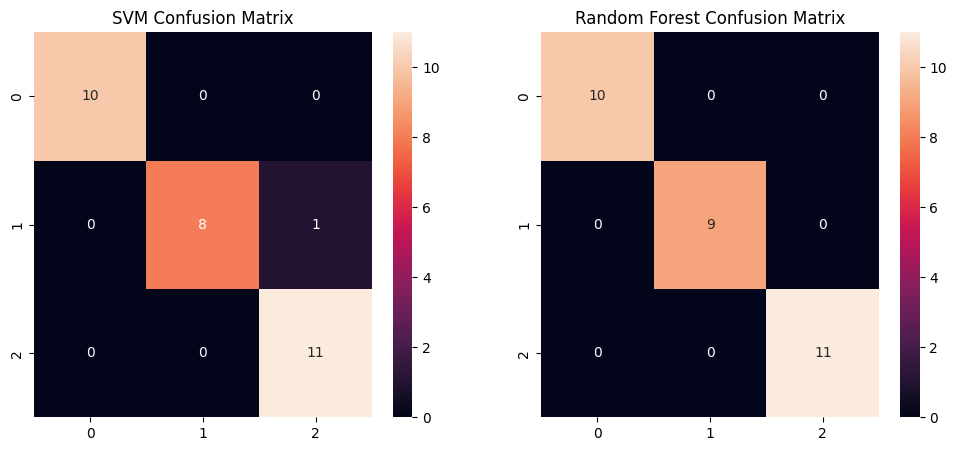

In [10]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(ytest, svm_preds), annot=True, ax=axes[0])
sns.heatmap(confusion_matrix(ytest, rf_preds), annot=True, ax=axes[1])
axes[0].set_title("SVM Confusion Matrix")
axes[1].set_title("Random Forest Confusion Matrix")
plt.show()

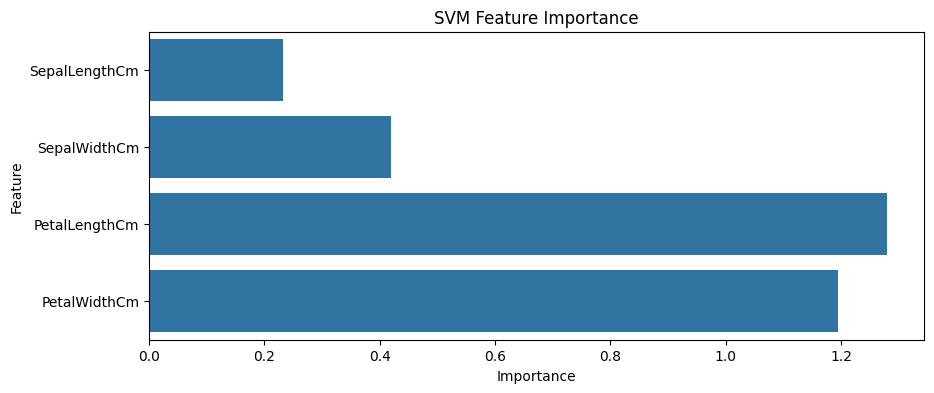

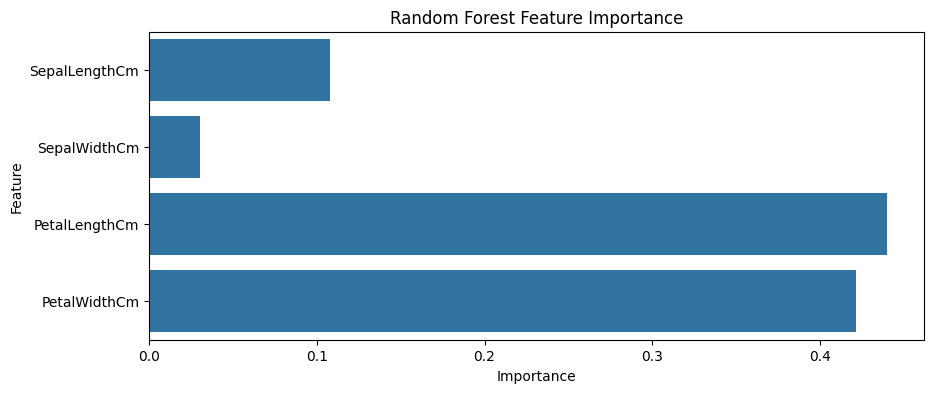

In [11]:
# Feature Importance
importances_svm = np.abs(svm.coef_).mean(axis=0)
importances_rf = rf.feature_importances_

plt.figure(figsize=(10, 4))
sns.barplot(x=importances_svm, y=x.columns)
plt.title('SVM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x=importances_rf, y=x.columns)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()